In [26]:
import filtering_util
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import pandas as pd

# Filtering gaze data
This exercise introduces different techniques for processing and analyzing gaze data using filtering. In particular the exercise removing noise and identifying fixations and saccades in the signal. A _fixation_ is defined as an instance with little or no eye movement. A _saccade_ is an eye movement between two fixations as illustrated in [Figure 1](#fix_sacc) for an example (image from [researchGate](https://www.researchgate.net/publication/356796000_TECHNICAL_MANUALS_READING_STRATEGIES_OF_PRIMARY_TEACHER_TRAINESS/figures?lo=1)
).
<div class="has-text-centered">
<figure class="image is-inline-block" id="fix_sacc">

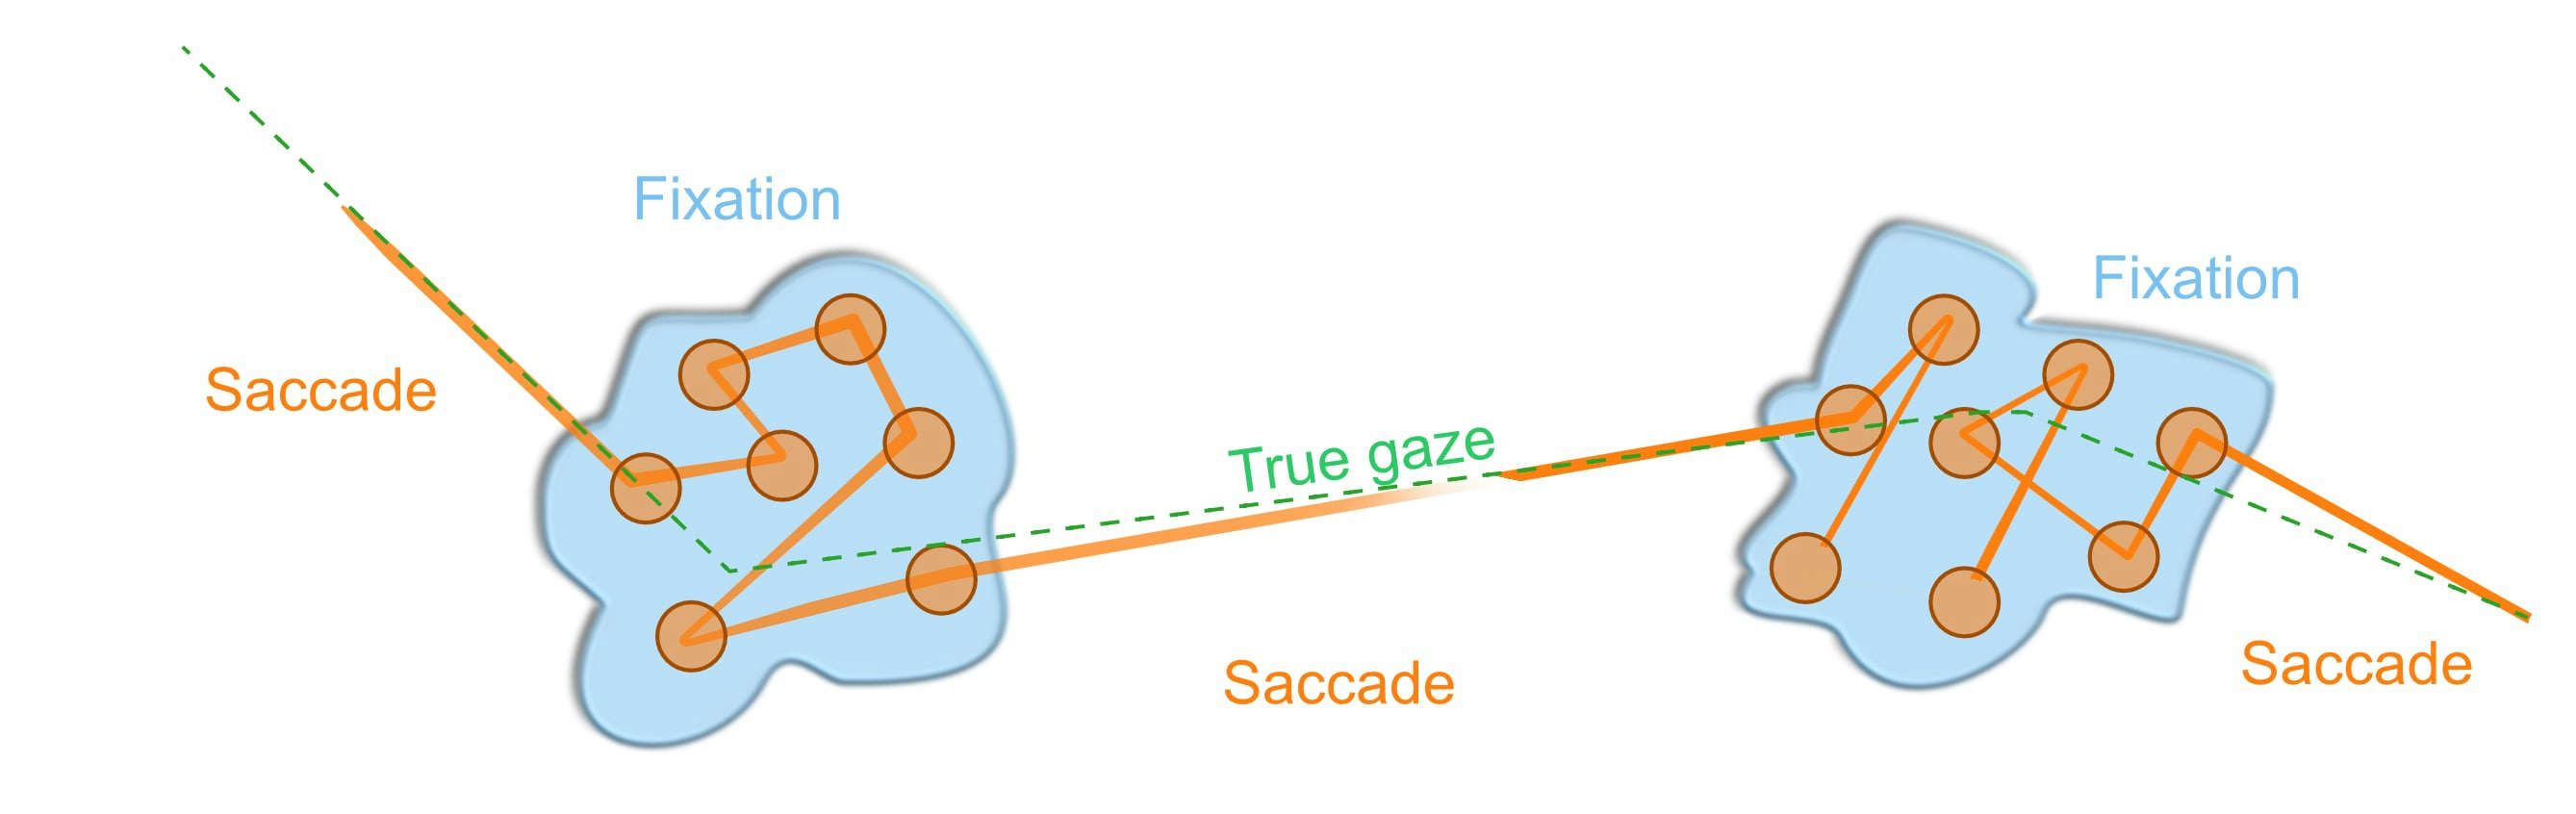

<figcaption class="figure-caption has-text-centered">Figure 1: Fixation and saccades in gaze data.
</figcaption>
</figure>
</div>
The visualizations presented throughout the exercise are based on data collected from `test_subject_1`
 using the `grid`
 pattern.
The exercise contains functions in the `filtering_util.py`
 file to create plots. 

<article class="message">
    <div class="message-body">
        <strong>List of individual tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#task_load_data">Task 1: Load the data</a>
            </li>
            <li>
            <a href="#task_gauss1">Task 2: Gaussian filter</a>
            </li>
            <li>
            <a href="#task_gauss2">Task 3: Implementing gaussian filter</a>
            </li>
            <li>
            <a href="#task_gauss3">Task 4: Reflect on applying gaussian filter</a>
            </li>
            <li>
            <a href="#task_gauss4">Task 5: Partial derivatives</a>
            </li>
            <li>
            <a href="#partial1">Task 6: Calculate the derivatives</a>
            </li>
            <li>
            <a href="#partial2">Task 7: Derivatives of a signal</a>
            </li>
            <li>
            <a href="#partial3">Task 8: Saccade detection</a>
            </li>
            <li>
            <a href="#partial4">Task 9: Saccade detection</a>
            </li>
            <li>
            <a href="#fixations1">Task 10: Fixation detection</a>
            </li>
            <li>
            <a href="#fixations2">Task 11: Visualization of signals</a>
            </li>
            <li>
            <a href="#fixation3">Task 12: Noise handling during fixations</a>
            </li>
            <li>
            <a href="#fixation4">Task 13: Frame grouping</a>
            </li>
            <li>
            <a href="#results1">Task 14: Evaluate</a>
            </li>
            <li>
            <a href="#owndata">Task 15: Combined signal</a>
            </li>
            <li>
            <a href="#combined1">Task 16: Combined signal</a>
            </li>
            <li>
            <a href="#combined2">Task 17: Reflect</a>
            </li>
        </ul>
    </div>
</article>

**Note:** Although the number of tasks is substantial, each requires minimal programming effort, with many tasks primarily necessitating reflection on the outcomes.


---
**Task 1 (easy): Load the data👩‍💻**
1. Run the cell to visualize the `grid`
 pattern of `test_subject_1`
.
**Note:** The code is loading the data from the folder of week 6. Alternatively you can copy the data to the folder of this exercise and change the file path accordingly.




---

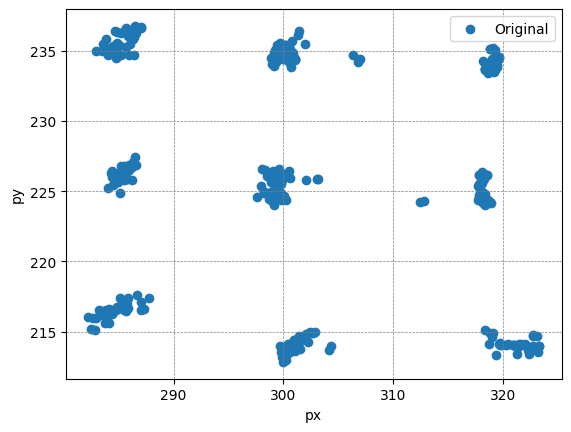

In [ ]:
test_subject = 'test_subject_1'
trial = '20250820_T0'
pattern = 'grid'

pupil_coordinates =f'../W02/sessions/{test_subject}/{trial}/{pattern}/frames/pupil_coordinates.csv'
mean_pupil_coordinates = f'../W02/sessions/{test_subject}/{trial}/{pattern}/mean_pupil_coordinates.csv'


pupil_coor= filtering_util.load_csv1(pupil_coordinates)


filtering_util.plot_pupil_coor(pupil_coor['px'], pupil_coor['py'], 'Original')
plt.show()

The next task involves visualizing the pupil coordinates signals `px`
 and `py`
 for the gaze `grid`
 pattern. In this task, a $1D$ Gaussian filter will be applied to smooth the signals individually. [Figure 2](#gauss) illustrates the Gaussian $1D$ filters and the corresponding filtered signal. The cell below convolves a Gaussian filter to gaze data. 
<div class="has-text-centered">
<figure class="image is-inline-block" id="gauss">

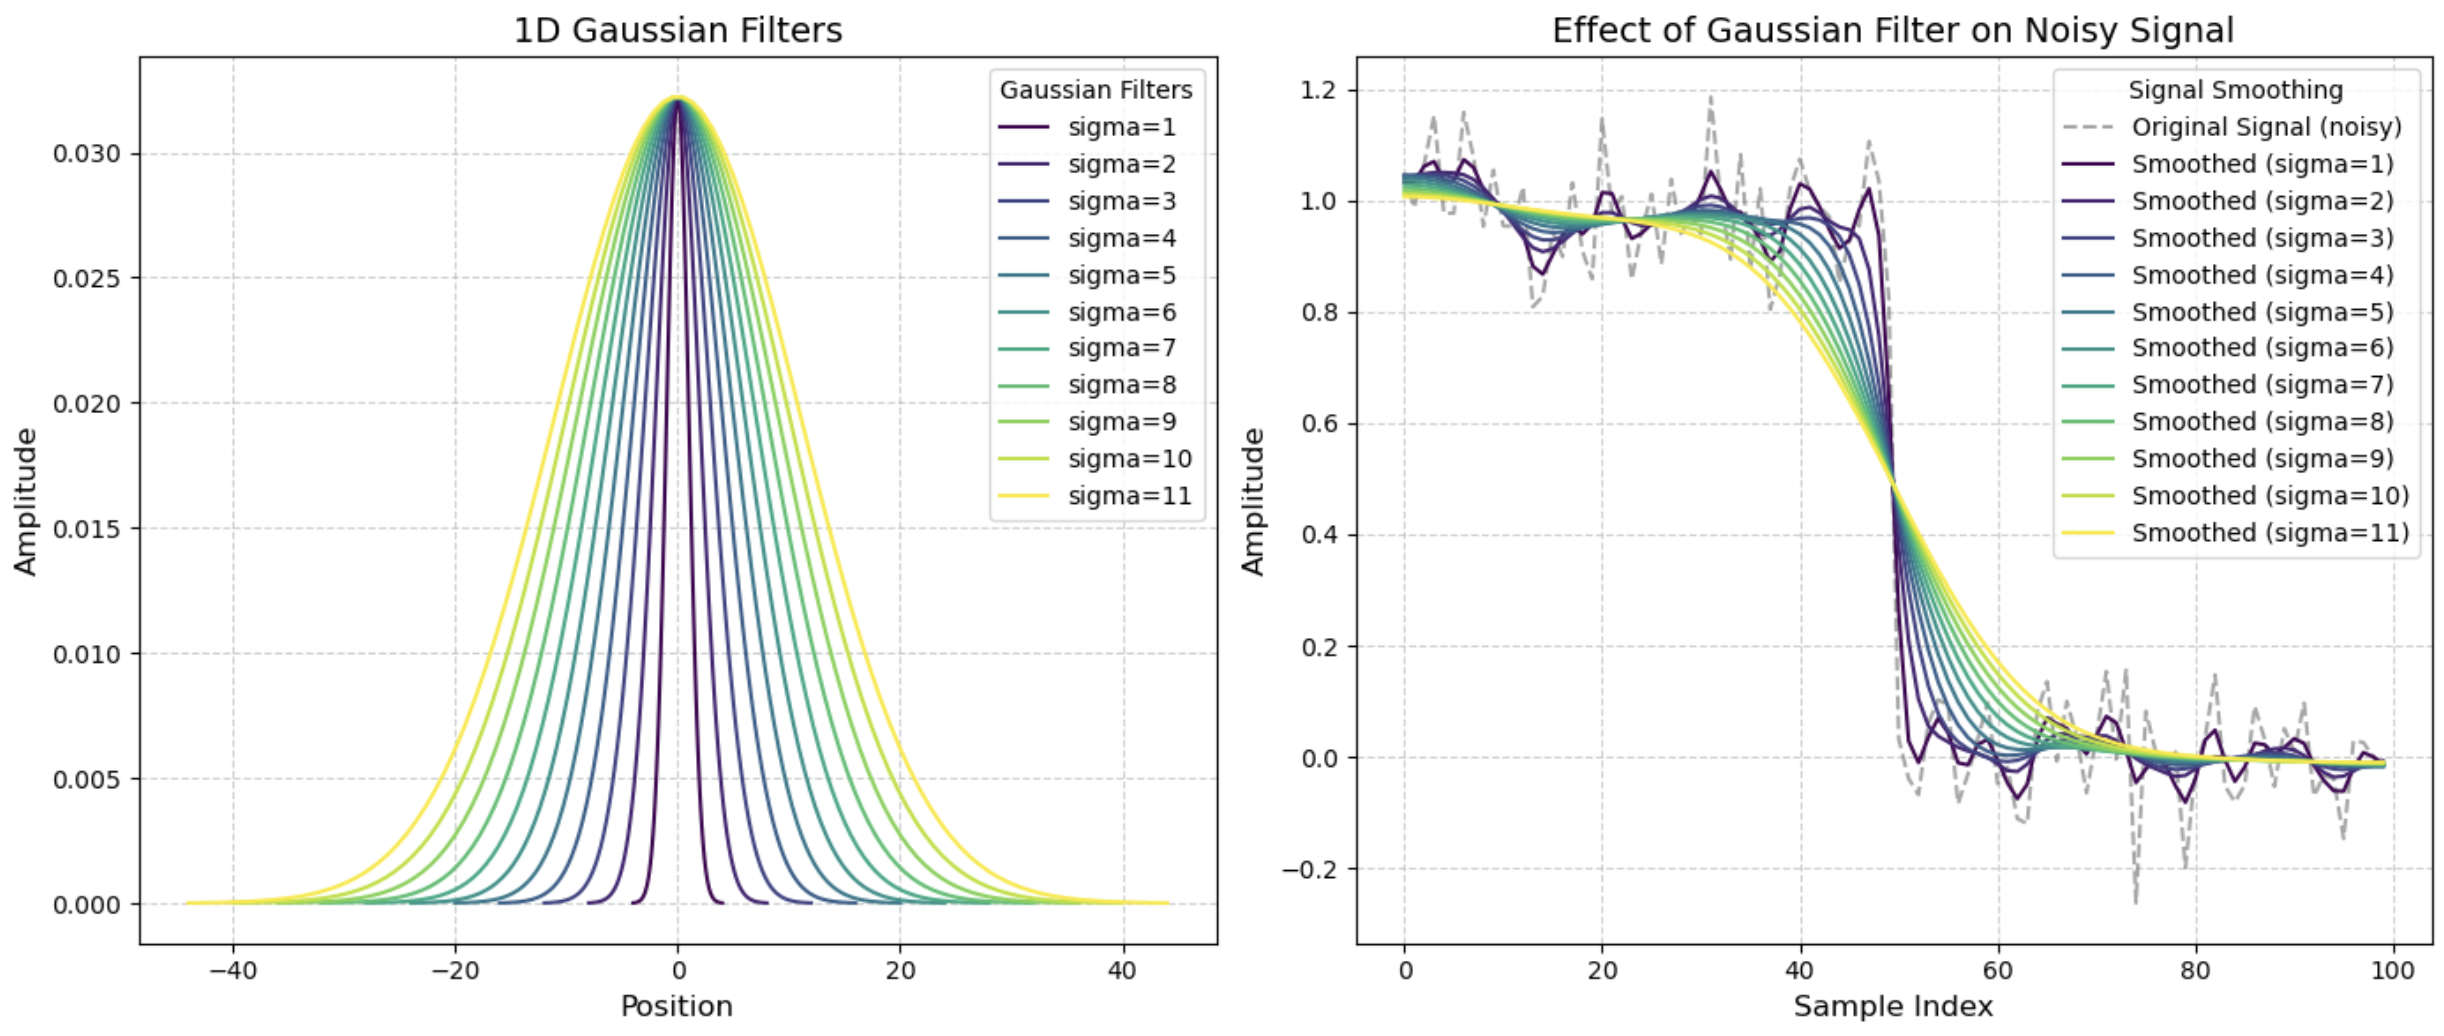

<figcaption class="figure-caption has-text-centered">Figure 2: Left: Shows the shape of the Gaussian filter for each value of sigma. Right: Demonstrates the effect of smoothing the noisy signal with each Gaussian filter.
</figcaption>
</figure>
</div>

---
**Task 2 (easy): Gaussian filter💡📽️**
1. Explain what is a Gaussian filter and how Gaussian filters can be applied to the data.
2. Reflect on the effect of applying a Gaussian filter to the data and how this can affect the subsequent proccessing of the gaze signal.


---

## 1. What is a Gaussian filter and how can it be applied to the data?

A **Gaussian filter** is a smoothing filter that applies a Gaussian function (bell-shaped curve) to data points. It works by convolving the signal with a Gaussian kernel, where each output value is a weighted average of neighboring input values, with weights determined by the Gaussian distribution.

**Key characteristics:**
- The filter is defined by its standard deviation parameter (σ, sigma), which controls the amount of smoothing
- Larger sigma values result in more smoothing (stronger blurring effect)
- Smaller sigma values preserve more detail but remove less noise
- The Gaussian function gives more weight to nearby points and less weight to distant points

**How it can be applied to gaze data:**
- For 1D gaze signals (like pupil coordinates px and py), we use `gaussian_filter1d()` from scipy
- The filter is applied independently to each coordinate (x and y) to smooth the signal
- The sigma parameter controls the smoothing strength - a good value balances noise removal while preserving important signal features like fixations and saccades

## 2. Effect of applying a Gaussian filter and impact on subsequent processing

**Effects on the data:**
- **Noise reduction**: High-frequency noise (small random fluctuations) is suppressed, making the signal smoother
- **Signal preservation**: Low-frequency components (like fixations and saccades) are largely preserved
- **Edge smoothing**: Sharp transitions are slightly smoothed, which can slightly blur the boundaries between fixations and saccades

**Impact on subsequent processing:**
- **Fixation detection**: Smoother signals make it easier to identify periods of stable gaze (fixations) by reducing false positives from noise
- **Saccade detection**: While smoothing helps reduce noise, it can also slightly blur the sharp transitions that characterize saccades, potentially affecting detection accuracy
- **Derivative calculations**: Smoothed signals produce more stable derivatives, which is beneficial for detecting velocity changes (important for saccade detection)
- **Trade-off**: There's a balance between noise removal and signal preservation - too much smoothing (high sigma) can remove important features, while too little (low sigma) may not effectively remove noise


---
**Task 3 (easy): Implementing gaussian filter👩‍💻**
1. Study the function `convolve_gauss`
 in the cell below.
2. Apply a Gaussian filter to the gaze data individually for `px`
and `py`
 signals. Use the function `plot_x_and_y`
 from `filtering_util.py`
 to visualize the result.    - The function takes two arrays of data as parameters.




---

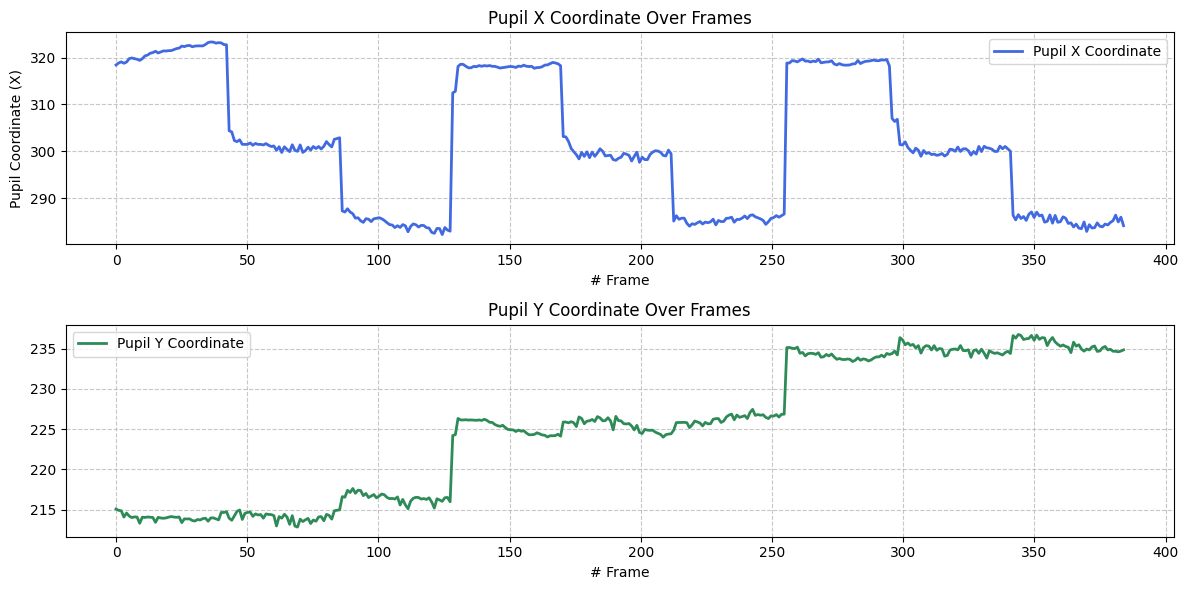

SIGMA=1


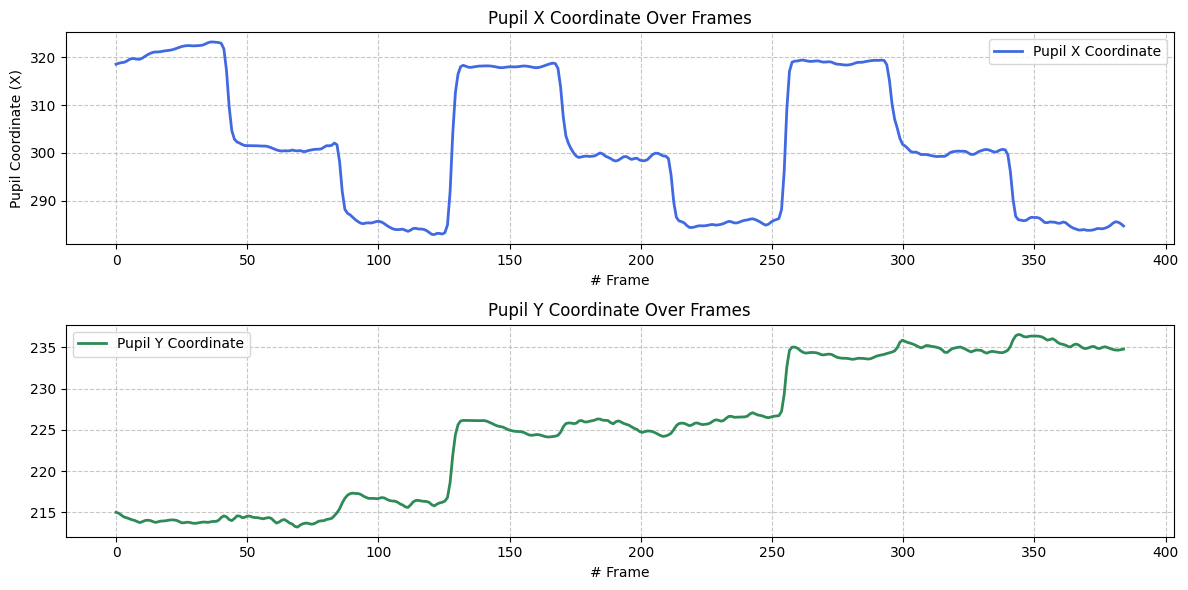

SIGMA=2


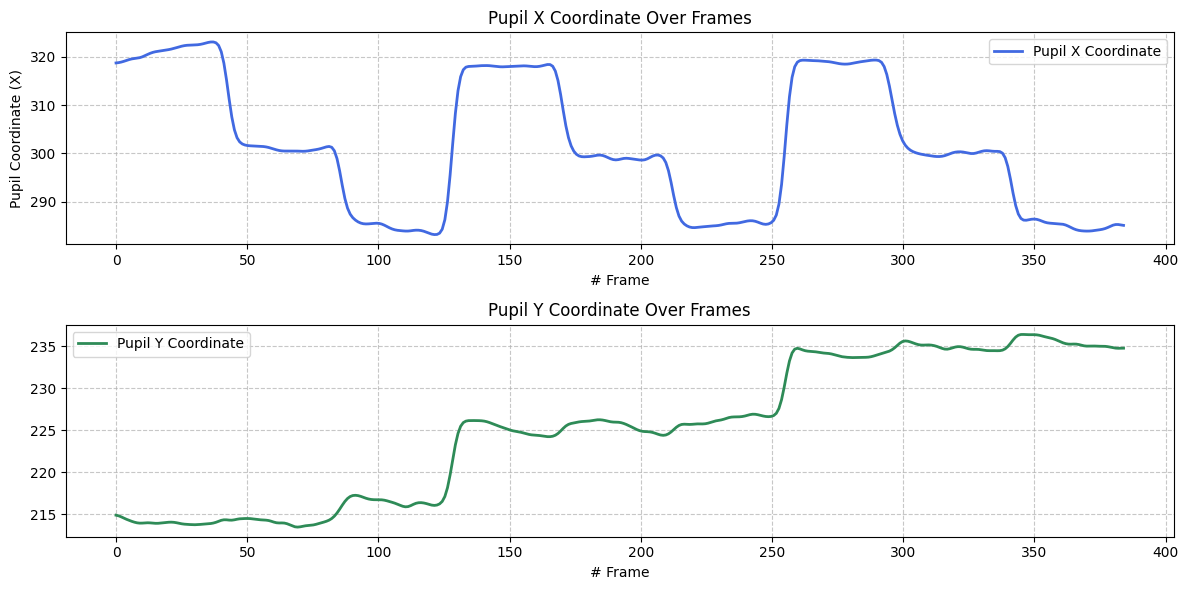

SIGMA=3


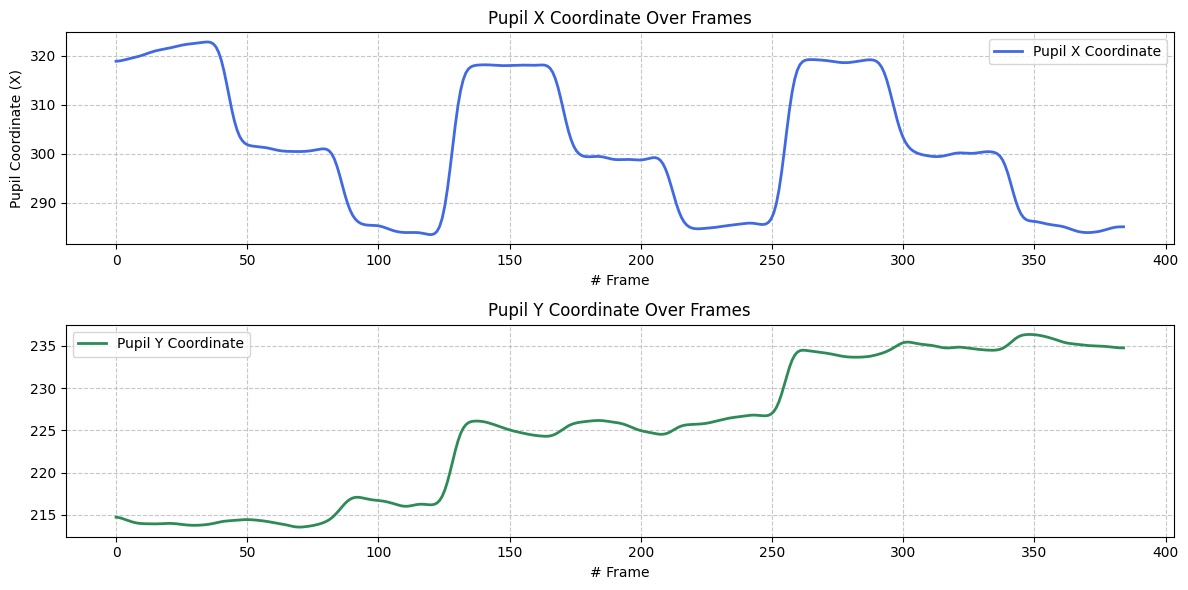

SIGMA=4


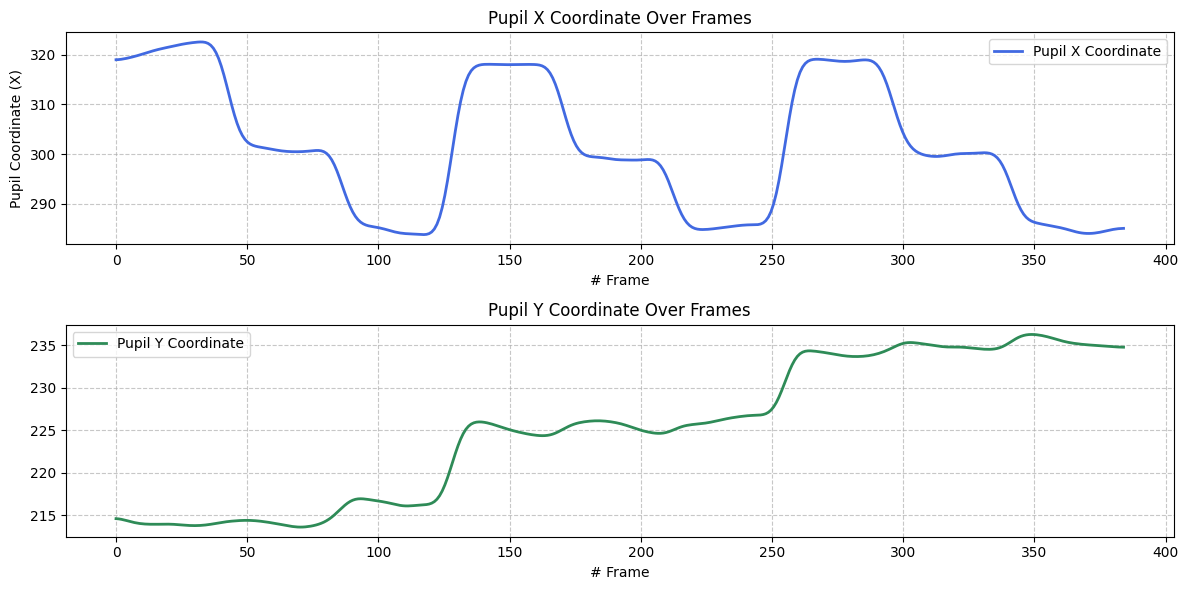

SIGMA=5


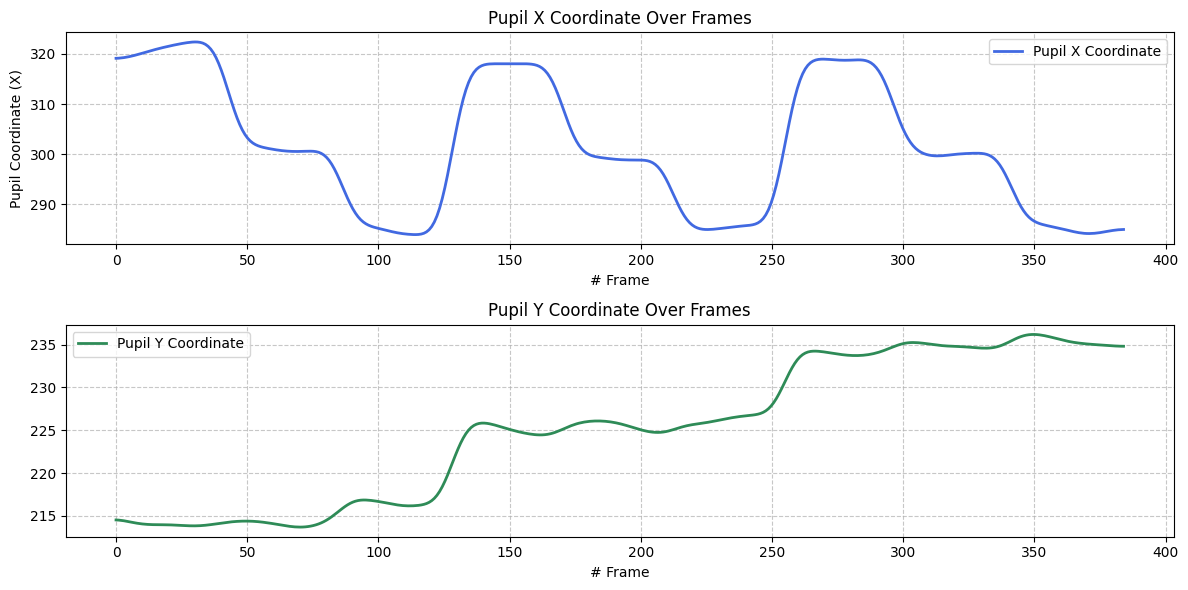

SIGMA=6


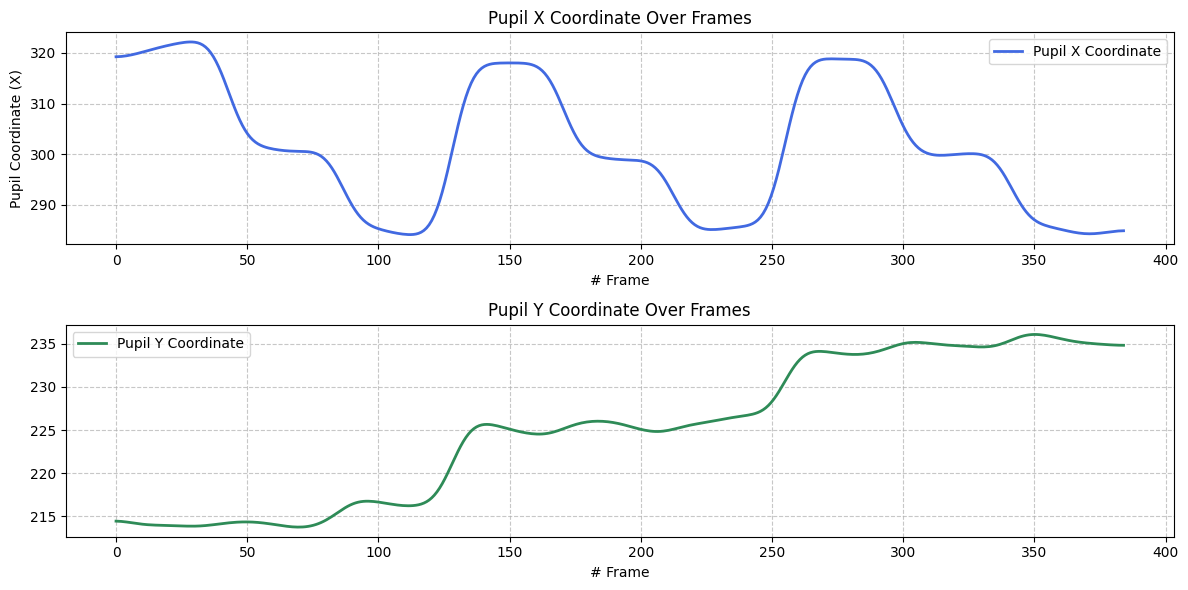

SIGMA=7


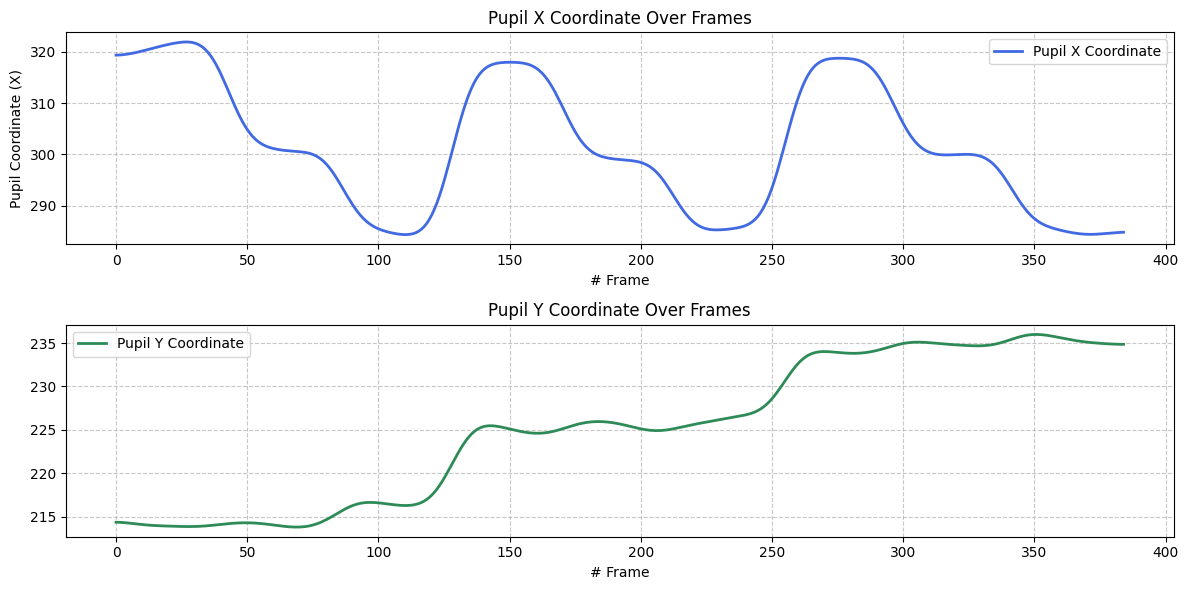

SIGMA=8


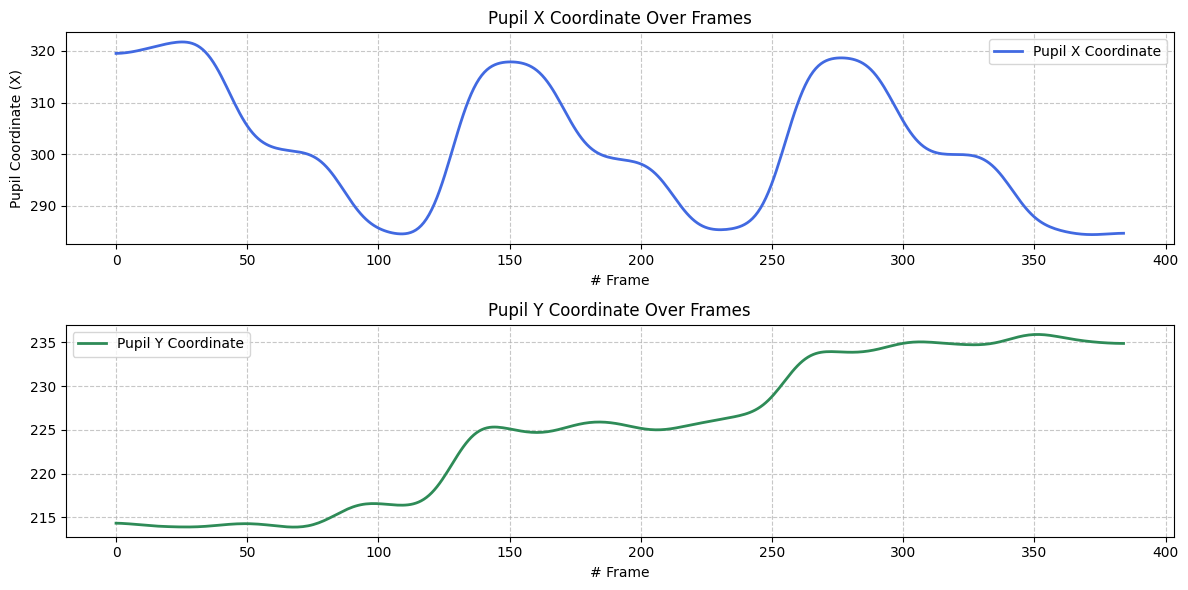

SIGMA=9


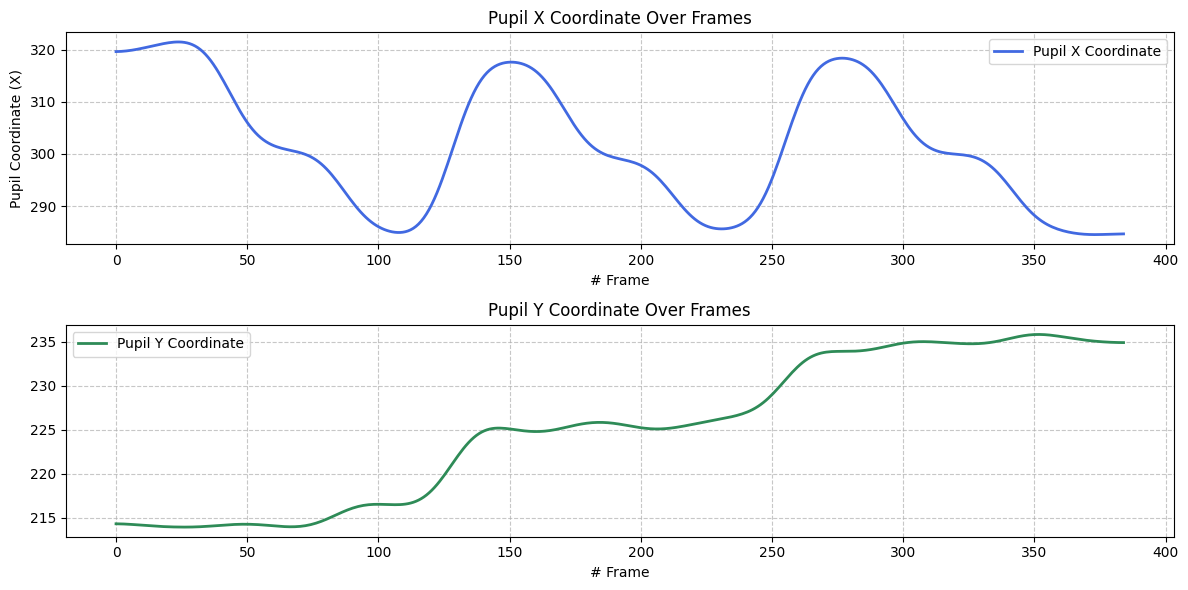

In [28]:
def convolve_gauss(data, sigma = 1):
    filtered = gaussian_filter1d(data, sigma=sigma, order = 0)
    return filtered



px = np.asarray(pupil_coor['px'])
py = np.asarray(pupil_coor['py'])

filtering_util.plot_x_and_y(px, py)

sigmas = range(1,10)
for sig in sigmas:
    print(f"SIGMA={sig}")
    filtered_x = convolve_gauss(px, sigma=sig)
    filtered_y = convolve_gauss(py, sigma=sig)
    filtering_util.plot_x_and_y(filtered_x, filtered_y)

sig = 5
filtered_x = convolve_gauss(px, sigma=sig)
filtered_y = convolve_gauss(py, sigma=sig)


---
**Task 4 (easy): Reflect on applying gaussian filter👩‍💻💡**
1. Characterize the signal and the noise. 
2. Experiment with the `sigma`
 parameter, which value of sigma removes the noise, but maintains the signal? 
3. Explain the effect of changing `sigma`
 on the data.
4. For which value of `sigma`
 does the important features of the signal start to disappear?


---

In [29]:
#1: The signal is the switching between 3 levels (i.e. bottom, middle, top | left, middle, right)
# # The noise are the small fluctuations/variation around the signal, i.e. within a fixation.

# 2: I prefer around sigma = 4, as we here have a smooth curve with minimal fluctuations while
# # still maintaining some of the rapid shifts between fixations - these get too rounded on larger sigma

# 3: Larger sigma smooth both the fixation variation but also the transitions (saccades) - i.e. making
# # it easier to detect constant state and harder to detect a changing state.

# 4: Around sigma = 5 / 6 the saccades in the y-coordinates becomes blurry
# # Around sigma = 8, the fixations in the x-coordinates becomes indistinguishable

## Partials derivatives

---
**Task 5 (easy): Partial derivatives💡📽️**
1. Recall from the lecture the partial derivatives of a signal calculated by convolving using the filter `[-1, 1]`
. What would be the result of convolving with a derivative filter on data that has been smoothed by a Gaussian filter? Use the following questions to guide your answers:    - Why does this filter find the derivative of the signal?
    - Which information is gained by applying such filter to gaze data?
    - How can the output be used for further processing?
    - What is the influence of the `sigma`
 value in the Gaussian the filter when finding the partial derivatives?




---

## Result of convolving derivative filter on Gaussian-smoothed data

When a derivative filter `[-1, 1]` is applied to data that has been smoothed by a Gaussian filter, the result is a **smoothed derivative** of the signal. This combines the benefits of both operations: the Gaussian filter removes high-frequency noise, and the derivative filter extracts the rate of change.

## Why does the filter `[-1, 1]` find the derivative?

The filter `[-1, 1]` approximates the first derivative by computing the **finite difference** between consecutive data points:
- For a signal value at position `i`, the filter calculates `signal[i+1] - signal[i]`
- This is mathematically equivalent to the discrete approximation of the derivative: `df/dx ≈ (f(x+h) - f(x))/h`
- The filter essentially measures the **rate of change** or **slope** between adjacent points
- Positive values indicate increasing signal, negative values indicate decreasing signal, and values near zero indicate stable regions

## Information gained from applying the derivative filter to gaze data

Applying the derivative filter to gaze data provides several important pieces of information:

1. **Velocity information**: The derivative represents the **velocity** of eye movement at each point in time
2. **Saccade detection**: High derivative values (large changes) indicate rapid eye movements (saccades)
3. **Fixation identification**: Low derivative values (small changes) indicate periods of stable gaze (fixations)
4. **Movement direction**: The sign of the derivative indicates whether the eye is moving in the positive or negative direction
5. **Movement magnitude**: The absolute value of the derivative indicates the speed/intensity of movement

## How the output can be used for further processing

The derivative output is extremely useful for subsequent processing:

1. **Saccade detection**: By thresholding the absolute derivative values, we can identify saccades (rapid eye movements) where the derivative exceeds a certain threshold
2. **Fixation detection**: Low derivative values can help identify fixations (periods of stable gaze)
3. **Event classification**: The derivative helps distinguish between different types of eye movements (saccades, fixations, smooth pursuits)
4. **Noise filtering**: The combination of Gaussian smoothing followed by derivative calculation produces cleaner, more reliable velocity estimates
5. **Feature extraction**: The derivative can be used as a feature for machine learning models or further signal analysis

## Influence of sigma value in Gaussian filter on partial derivatives

The `sigma` parameter in the Gaussian filter has a significant influence on the resulting partial derivatives:

1. **Small sigma values**:
   - Preserve more high-frequency details
   - Derivatives are more sensitive to noise
   - Can detect smaller, faster movements
   - May produce noisy derivative signals with many false positives

2. **Large sigma values**:
   - Remove more noise but also smooth out important signal features
   - Derivatives are more stable but less sensitive
   - May miss small saccades or blur the boundaries between fixations and saccades
   - Produce smoother derivative curves but potentially lose important information

3. **Optimal sigma**:
   - Balances noise removal with signal preservation
   - Produces derivatives that are stable enough to reduce false positives while still capturing important eye movement events
   - The optimal value depends on the noise level in the data and the characteristics of the eye movements being studied

**Key insight**: Since differentiation amplifies noise, applying a Gaussian filter **before** taking the derivative is crucial. The Gaussian filter reduces noise, making the derivative calculation more reliable. However, there's a trade-off: too much smoothing (high sigma) can remove important signal features, while too little smoothing (low sigma) can result in noisy derivatives that are difficult to interpret.

The following task is about implementing a method to find derivatives a signal using the filter $[-1, 1]$. 
The function `plot_x_and_y_complete`
 from `filter_util.py`
 takes two dictionaries one for each coordinates and plots the signals. The dictionaries should contain keys value pairs of the original and processed signal. 

---
**Task 6 (easy): Calculate the derivatives👩‍💻**
1. Complete the function `get_partial_derivatives`
 to apply the derivative filter to a signal and return the absolute value of the result. Use [np.convolve](https://numpy.org/doc/2.0/reference/generated/numpy.convolve.html)
 for convolution. The **absolute value** of the derivative is used as only the rate of change is of interest. 


---

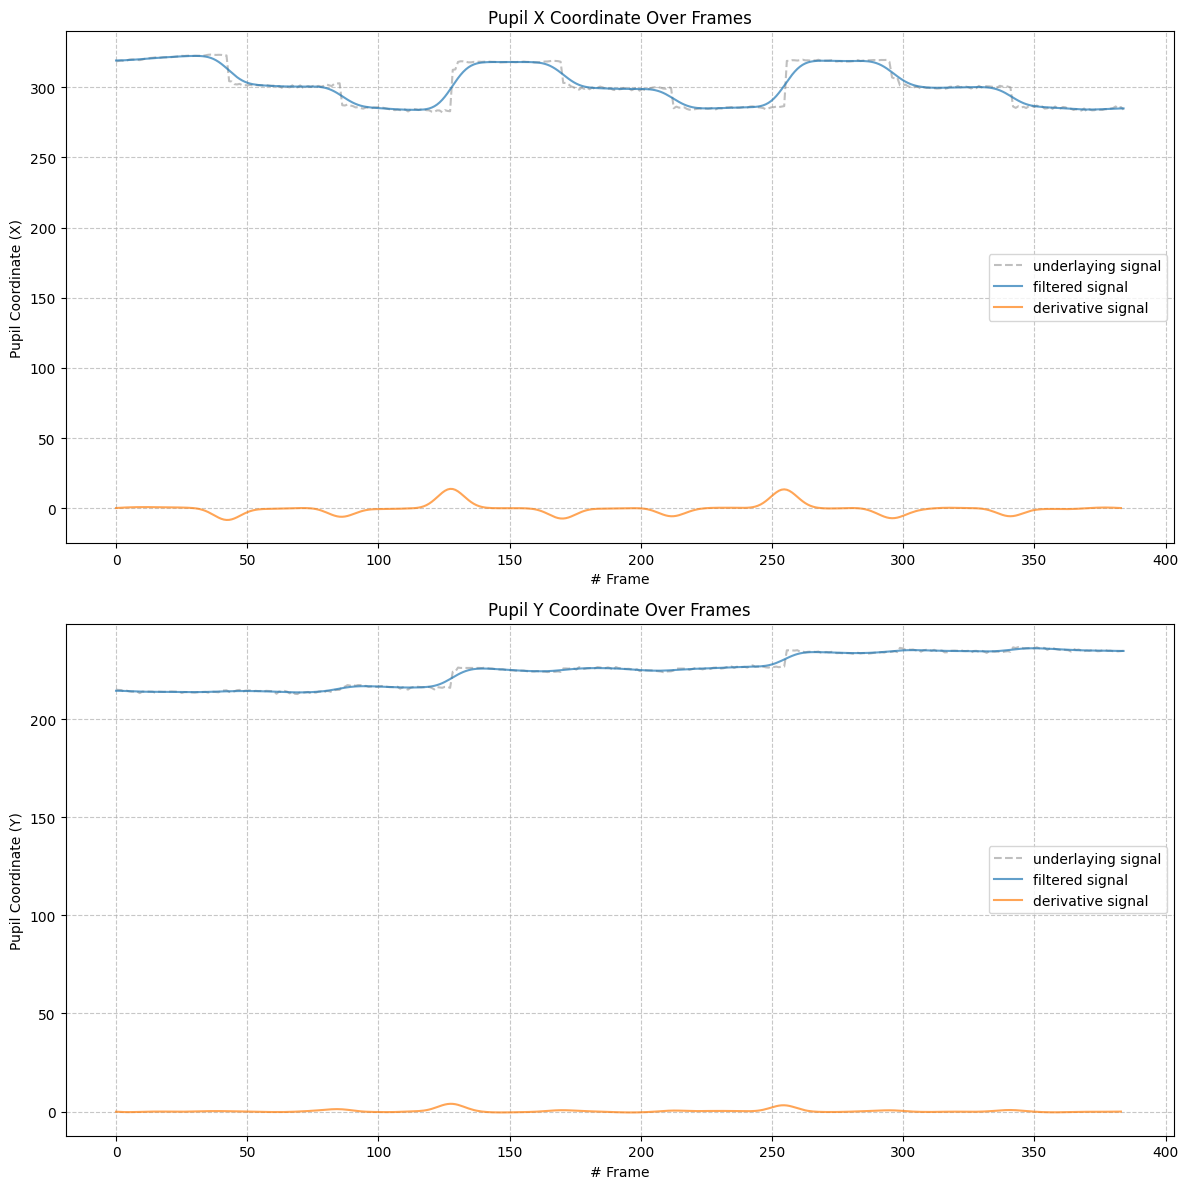

In [30]:
def get_partial_derivatives(data):
    """
    Convolve 1D data with a [-1, 1] filter.

    Args:
        data (numpy array): 1D array of data.

    Returns:
        numpy array: Convolved result.
    """
    return data[1:] - data[:-1]

der_x = get_partial_derivatives(filtered_x)
der_y = get_partial_derivatives(filtered_y)

x_collected = {'underlaying': px, 'filtered': filtered_x, 'derivative': der_x}
y_collected = {'underlaying': py, 'filtered': filtered_y, 'derivative': der_y}

filtering_util.plot_x_and_y_complete(x_collected, y_collected)


---
**Task 7 (easy): Derivatives of a signal💡📽️**
1. Inspect the plots above and reflect on the relation between the original signals, the filtered and the derivative of the filtered signals. In your reflections you may include:    - What charateristics in the gaze data do the peaks and plateaus encapsulate, use the data collection session to elaborate. 
    - What behaviour is expected for the `x`
 coordinate of the pupil?
    - What behaviour is expected for the `y`
 coordinate of the pupil?
    - What would happen with these if if the pattern was changed?




---

In [31]:
# 1: the peaks in the derivative encapsulates saccades (changing to a new fixation point) and close-to-0
# # derivates are fixations. in the filtered signals the plateaus also indicate fixations,
# # while the rapid changes indicate saccades.

# 2: The x-coordinate should start with a plateau in the top, moving down twice and then
# # return back to the top (plateauing in each place a total of 3 times)

# 3: The coordinate should remain plateaued in the bottom before moving up twice.
# # (plateauing in each place once)

# 4: If the pattern was different, then the plateaus would be in different places and patterns.
# # if the duration of a fixation point was changed, the duration of a plateaus should also change.

The following task are about detecting events (fixations and saccades) in eye signals using derivative filters.

---
**Task 8 (easy): Saccade detection👩‍💻**
1. Complete the function `saccade_detection`
. The function should identify indices for _saccades_ (large eye movements) using the derivatives of the smoothed signal.
2. Use the function `saccade_detection`
 to detect saccades in `der_x`
 and `der_y`
.


---

In [45]:
def saccade_detection(signal, threshold=3.0):
    """
    Saccade detection: 
        Mark indices where the signal exceeds a threshold.

    Parameter:
        signal (list): derivative signal
        threshold (float): threshold marking a spike in the signal
    

    return: list of saccade indices
    """
    
    saccades = []
    for i, v in enumerate(signal):
        if abs(v) > threshold: # ADDED ABS TO DETECT NEGATIVE SACCADES
            saccades.append(i)
    return saccades

x_saccades = saccade_detection(der_x, threshold=1)
y_saccades = saccade_detection(der_y, threshold=0.5)


---
**Task 9 (easy): Saccade detection👩‍💻**
1. Run the cell below to visualize the detected saccades.


---

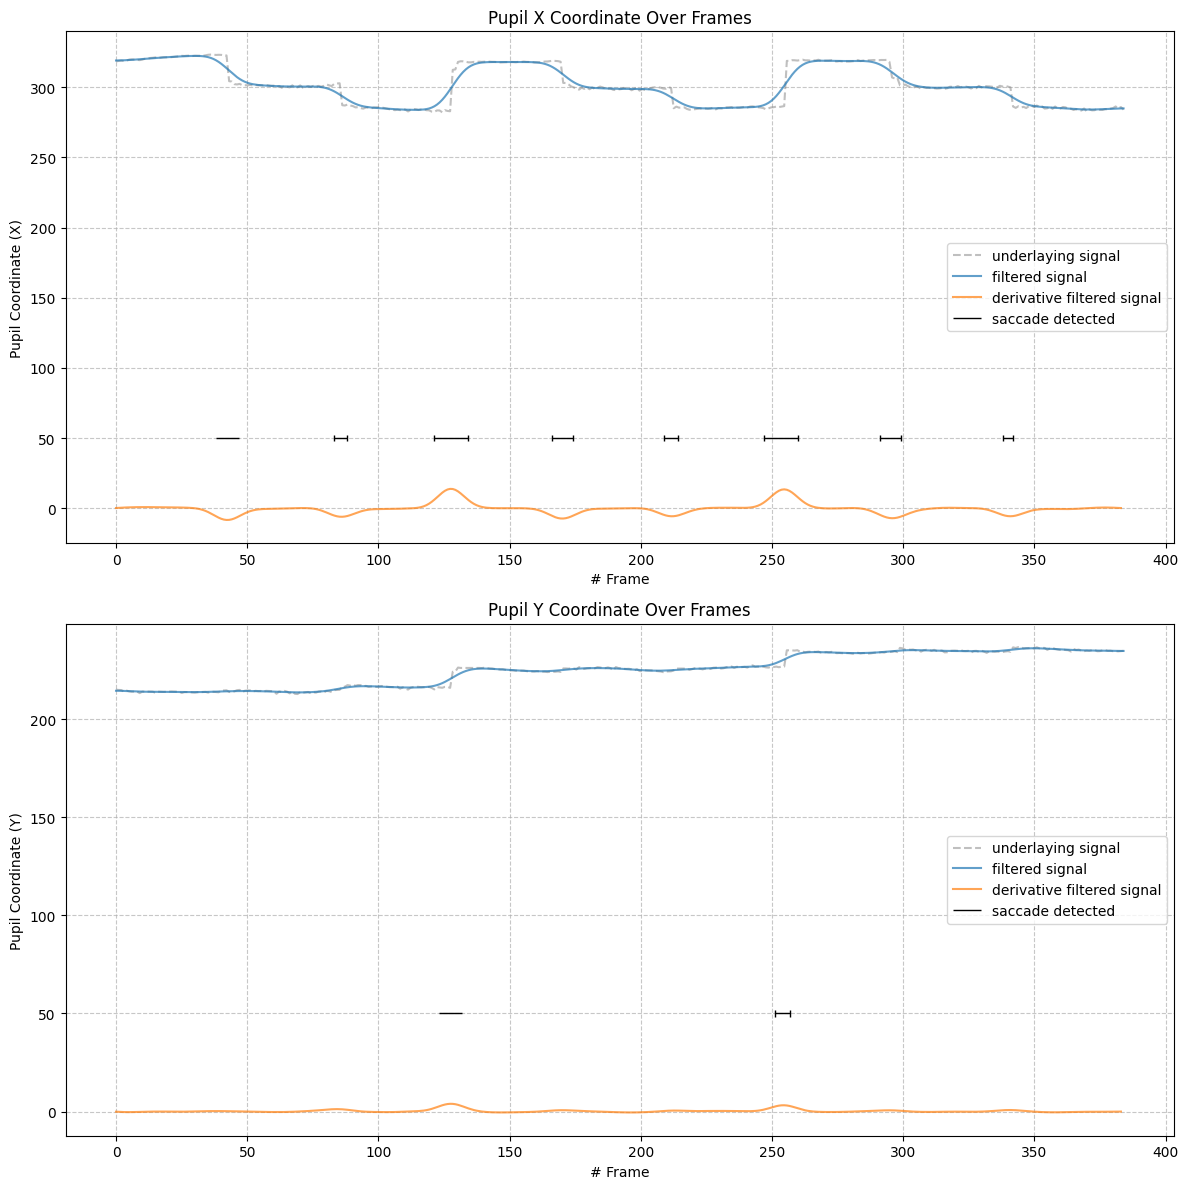

In [46]:
x_saccade = {'underlaying': px, 'filtered': filtered_x, 'derivative filtered': der_x, 'saccade': x_saccades}
y_saccade = {'underlaying': py, 'filtered': filtered_y, 'derivative filtered': der_y, 'saccade': y_saccades}

filtering_util.plot_x_and_y_complete(x_saccade, y_saccade)


---
**Task 10 (easy): Fixation detection👩‍💻**
This task is about using the saccades to identify individual fixation points.
1. Complete the function `fixation_filtering`
. The function should use the output of the `saccade_detection`
 to remove all saccades by overwriting the saccade indices with the latest known fixation point.

**Note:** This may not be the most optimal way of handling saccades, but it serves the purpose of this exercise

`fixation_filtering`
`get_partial_derivatives`
`saccade_detection`

---

In [57]:
def fixation_filtering(px, py, x_saccades, y_saccades):
    """
    Removes saccades from the input data based on detected indices for saccades. If a spike is detected
    at a given index, the previous valid vafixationlue is used to replace the current value.
    Parameters:
        px (1 x N nupy array): Representing the x coordinates (input signal).
        py (1 x N nupy array): Representing the y coordinates (input signal).
        x_saccades (list): A list of indices where saccades are detected in the x direction.
        y_saccades (list): A list of indices where saccades are detected in the y direction.
    Returns:
    px_new (list): A list of the cleaned x coordinates.
    py_new (list): A list of the cleaned y coordinates.
    """
    px_cleaned = []
    py_cleaned = []

    x_fill = px[0]
    y_fill = py[0]
    for i, curr in enumerate(zip(px, py)):
        curr_x, curr_y = curr

        if i in x_saccades:
            px_cleaned.append(x_fill)
        else:
            px_cleaned.append(curr_x)
            x_fill = curr_x
        
        if i in y_saccades:
            py_cleaned.append(y_fill)
        else:
            py_cleaned.append(curr_y)
            y_fill = curr_y
    # Write your implementation
    return px_cleaned, py_cleaned



cleaned_px, cleaned_py = fixation_filtering(filtered_x, filtered_y, x_saccades, y_saccades)
der_x_cleaned = get_partial_derivatives(np.array(cleaned_px))
der_y_cleaned = get_partial_derivatives(np.array(cleaned_py))
x_saccades_cleaned = saccade_detection(der_x_cleaned, threshold=1)
y_saccades_cleaned = saccade_detection(der_y_cleaned, threshold=0.5)


---
**Task 11 (easy): Visualization of signals👩‍💻**
1. Run the cell below to visualize the fixations and saccades.


---

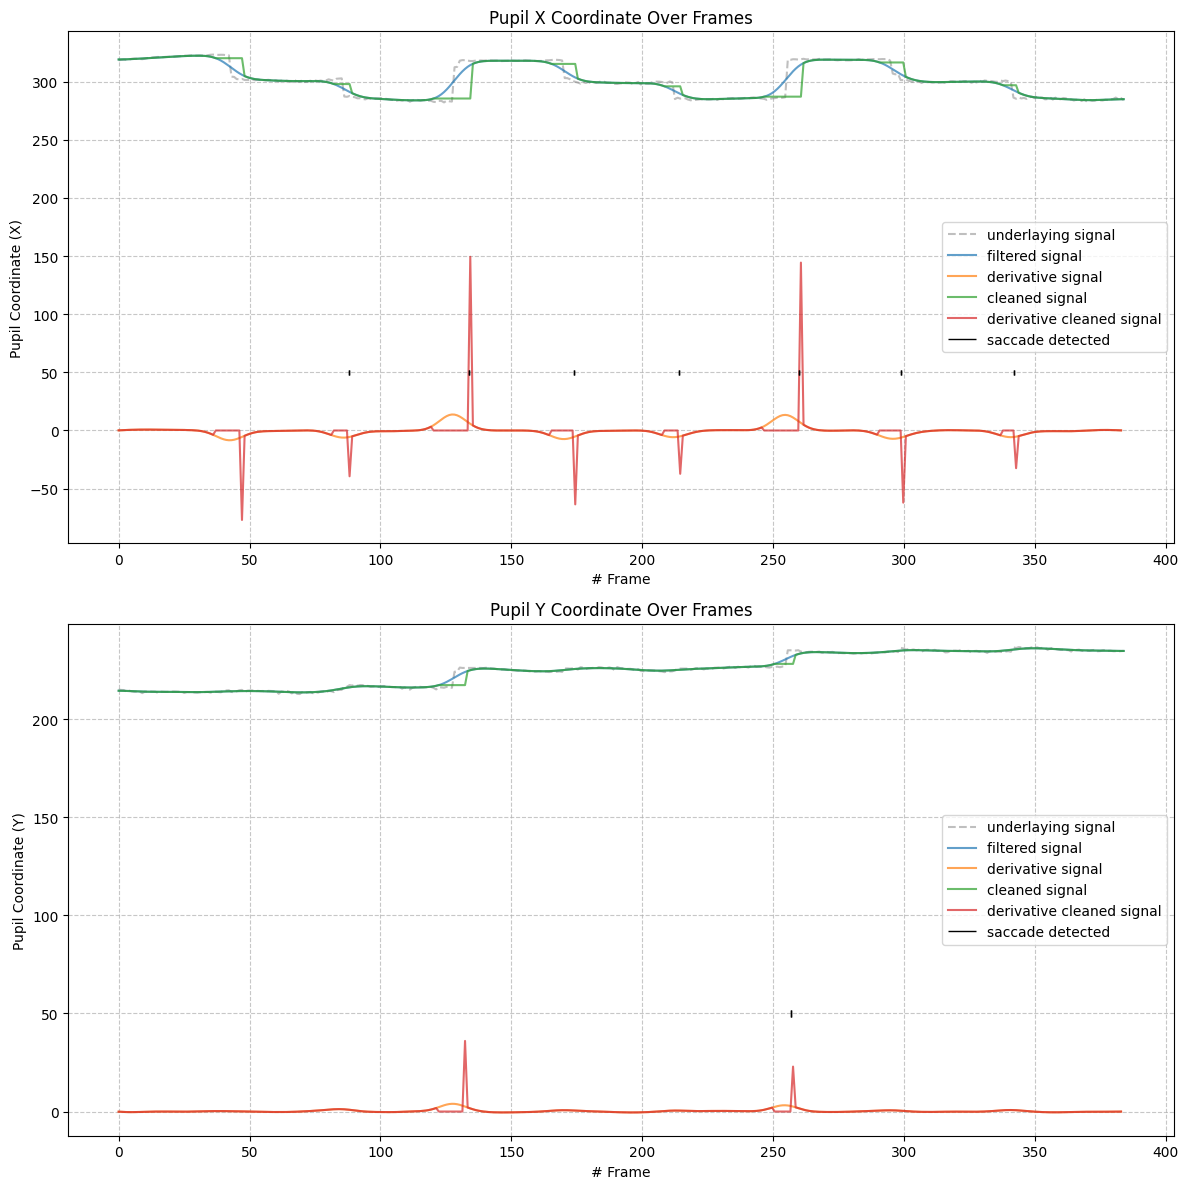

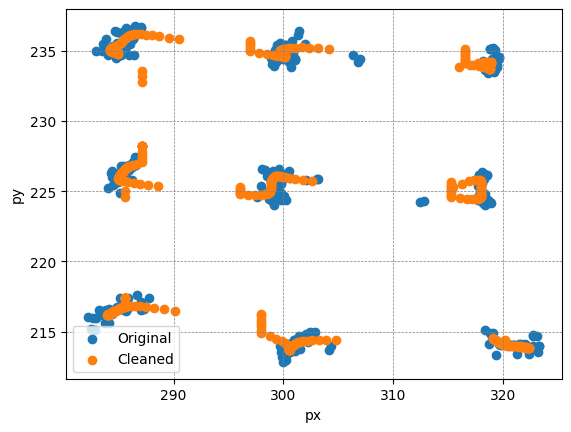

In [58]:
x_collected['cleaned'] = cleaned_px
y_collected['cleaned'] = cleaned_py

x_collected['derivative cleaned'] = der_x_cleaned
y_collected['derivative cleaned'] = der_y_cleaned

x_collected['saccade detected'] = x_saccades_cleaned
y_collected['saccade detected'] = y_saccades_cleaned

filtering_util.plot_x_and_y_complete(x_collected, y_collected, 5) #5 is a scaling factor on the values of the derivative for display purposes
filtering_util.plot_pupil_coor(px, py, 'Original')
filtering_util.plot_pupil_coor(cleaned_px, cleaned_py, 'Cleaned')
plt.show()


---
**Task 12 (easy): Noise handling during fixations💡📽️**
1. Reflect on the assumptions of your method for handling noise during fixations in [Task 10](#fixations1). What are the advantages and limitations of your approach if any?
2. Reflect on other strategies that you could use for handling the noise and outliers in the gaze data.


---

In [0]:
# 1: it does not do anything extra for noise during fixations? only makes the saccades sharper?
# # Limitations - need to be tuned for a specific dataset, as the sigma and thresholds vary
# # depending on the setup, and require manual validation of detections. 
# # the fixations are identified by the threshold as well, so we somehow also assume that the
# # points are far enough that the threshold will detect the change.

The next step is to utilize the charateristics of the derivative of the smoothed signal to detect the frames (pupil coordinates) corresponding to each screen calibration point, so the data can be sorted in corresponding input and label pairs.

---
**Task 13 (easy): Frame grouping👩‍💻**
1. Complete the function `get_frames_pupil_movement`
. The function should construct a dictionary where the keys represent the calibration point numbers (e.g., '0', '1', ..., '8'), and the associated values are tuples consisting of the start and end frame indicies.
2. Use the function `get_frames_pupil_movement`
 to determine the sections pupil corrdinate sections belonging to each calibration coordinate.


---

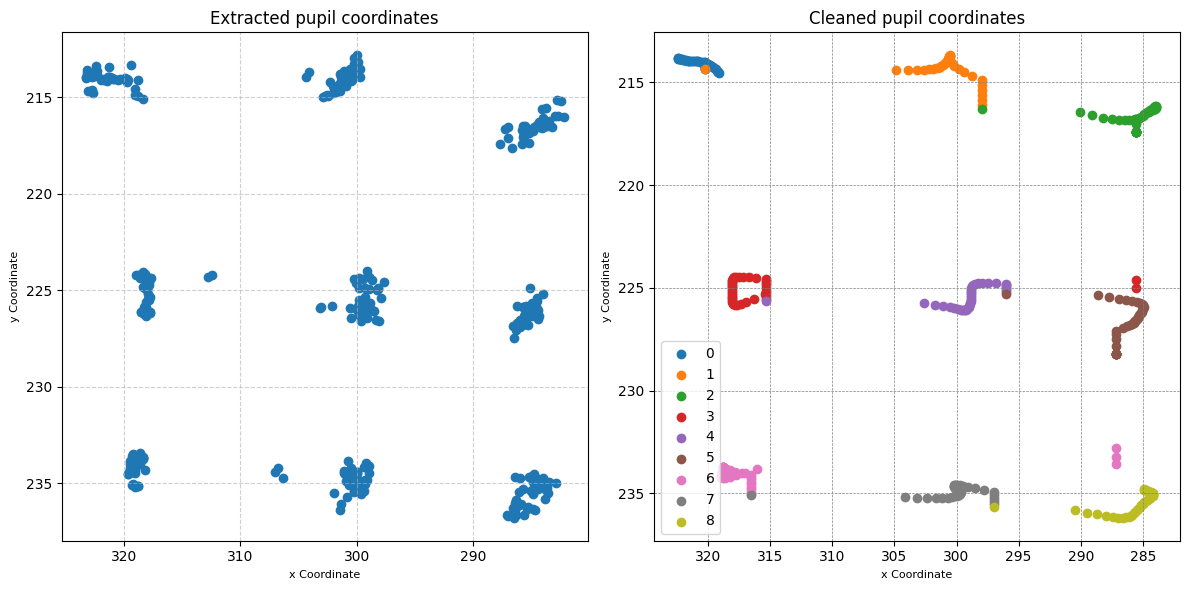

In [77]:
def get_frames_pupil_movement(cleaned_der, thresholds, data):
    """
    Identifies segments of pupil movement based on changes in the cleaned derivative.
    Parameters:
        cleaned_der (list or numpy array): A 1D array of the derivative values of the cleaned data, indicating changes in pupil position over time.
        data (list or numpy array): The original data corresponding to the pupil movement.

    Returns:
        dict ( {string: tuple(int, int)} ): A dictionary where the keys are calibration point numbers (as strings) and the values are tuples
              containing the start and end frame numbers for each segment.
    """
    frames = {}
    all_saccades = []

    for der, t in zip(cleaned_der, thresholds):
        all_saccades += saccade_detection(der, threshold=t)
    
    all_saccades.sort()

    prev = all_saccades[0]
    mean_saccades = []
    tmp = []
    for s in all_saccades:
        if s - prev > 5:
            mean_saccades.append(int(sum(tmp) / len(tmp)))
            tmp = [s]
        else:
            tmp.append(s)
        prev = s
    mean_saccades.append(int(sum(tmp) / len(tmp)))

    prev = 0
    for i in range(8):
        frames[str(i)] = (prev, mean_saccades[i])
        prev = mean_saccades[i]
    frames[str(8)] = (prev, len(data[0])-1)
    
    return frames
# Write your implementation
frames = get_frames_pupil_movement([der_x_cleaned, der_y_cleaned], [1, 0.5], [px, py])
filtering_util.plot_pupil_coordinates(frames, px, py, cleaned_px, cleaned_py)

## Analyzing results
In the following task the results of the filtering will be compared to the fixation identification made by the data collection script.

---
**Task 14 (easy): Analyse results👩‍💻**
1. Complete the function `evaluate_fixations_accuracy`
. The function should evaluate the fixation intervals from the filtering the signal, with the fixation noted during the datacollection. 
**Note:** During data collection, the frames are stored with naming `xx_yyyyyy.jpg`
 where xx marks the fixation the gaze in the frame belongs to.


2. Run the cell below to assess the performance of the filtered gazesignal separating fixation. 


---

0.9427083333333334


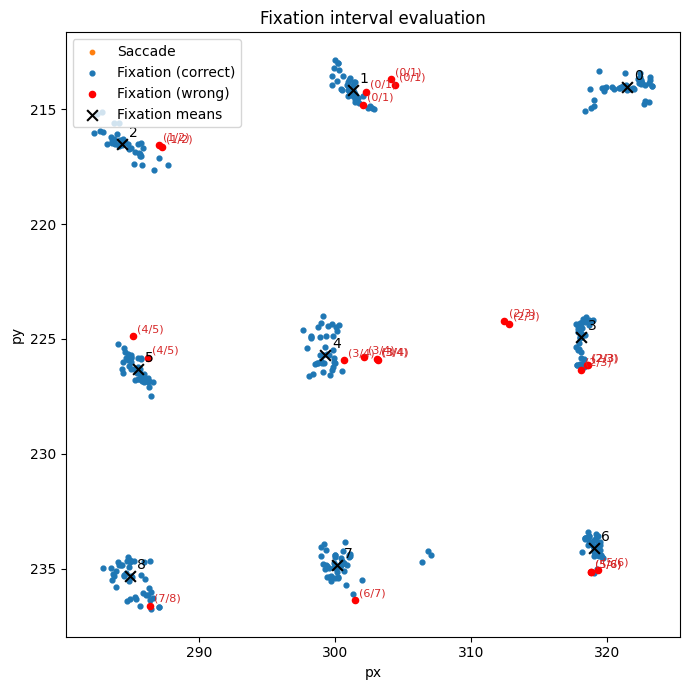

In [ ]:
def evaluate_fixations_accuracy(pupil_csv_path, frames_interval):
    """
    Evaluate sample-level accuracy of predicted fixation intervals.

    Parameters:
    csv_path : str
        Path to CSV file with pupil data. Must contain 'image' column
        where the first two characters encode the true fixation ID.
    frames_interval : frames dict
        Mapping of predicted fixation IDs to index ranges,
        e.g. {'0': (0,42), '1': (44,85), ...}.

    Returns:
    None
        Prints the sample-level accuracy (float between 0 and 1).
    """
    df = pd.read_csv(pupil_csv_path)
    df['true_fix'] = df['image'].str[:2].astype(int)
    
    matches = [i >= frames_interval[str(fix)][0] and i <= frames_interval[str(fix)][1] for i, fix in enumerate(df['true_fix'])]
    print(sum(matches) / len(matches))



evaluate_fixations_accuracy(pupil_coordinates, frames)

filtering_util.plot_fixation_eval(pupil_coordinates, frames, mean_pupil_coordinates)


---
**Task 15 (easy): Evaluate👩‍💻**
1. Inspect accuracy and the plot. Describe the points that were misclassified. Reason about the cause of the missclassification.


---

In [0]:
# Misclassified points are sometimes outside the main cluster, and may otherwise be misclassified due to
# the smoothing applied.

## Inspecting own data

---
**Task 16 (medium): Combined signal👩‍💻💡**
1. Go back to [Task 1](#task_load_data) and update the folder path to target the `grid`
 pattern of your own data.
2. Rerun the steps above.
3. Reflect on how well does the method generalizes to this dataset. You may use the following questions to guide your answers?    - How do the results differ from the ones of `test_subject_1`
?
    - Is it possible to reuse the same parameters or do they need to be updated?
    - Has the experimental setup any influence on the methods ability to generalizable? Why/why not?




---

In [0]:
# Have not run, but the following has relevance:
# 1: our data was more noisy than the given data, and might therefore need a higher threshold or
# # more smoothing to obtain good detections of saccades and fixations.

# 2: Parameters shoudl always be updated when the setup differs and also even if the pattern was different.

# 3: Yes, the setup is sensitive to how noise appears - both in terms of the individual person's eye
# # concentration as well as light and all the considerations done during the preprocessing to find pupil
# # coordinates - there are so many hyper parameters and ways this might go wrong that need to be specified
# # in accordance with the current setup.

## Event detection using gradients
In this task you will explore the combined signal (changes in x and y direction simultainously) and use the gradient for event detection. Recall the definition for the gradient of the function $f(x,y)$:

$$

\nabla f(x, y) = \left( \frac{\partial f(x,y)}{\partial x}, \frac{\partial f(x,y)}{\partial y} \right)


$$

You will use the gradient magnitude, the length of the gradient defined by:

$$
||\nabla f(x, y)|| = \sqrt{\Big(\frac{\partial f(x,y)}{\partial x}\Big)^2 + \Big(\frac{\partial f(x,y)}{\partial y} \Big)^2}
$$

---
**Task 17 (easy): Combined signal👩‍💻**
1. Complete the functions:    - `gradient_mangitude`
: The function should calculate the gradient magnitude of a $2D$ signal given `x`
 and `y`
.




---

In [82]:
import os
os.chdir('..')
from utils import *

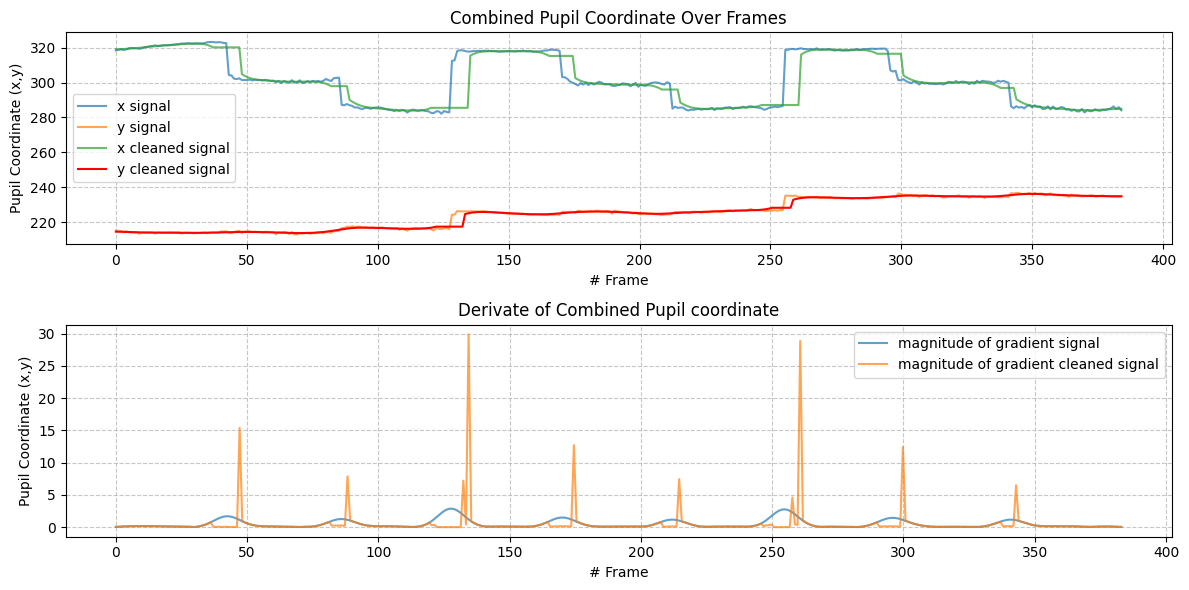

In [83]:
def gradient_mangitude(x, y):
    """
    Calculates the gradient mangitude in a 2D space.
    Args:
        x (N x 1 numpy array): Array of x coordinates.
        y (N x 1 numpy array): Array of y coordinates.
    
    Returns:
        (N x 1 numpy array): The Euclidean distance from the origin to the point (x, y).
    """
    return np.array([ListVector([xi, yi]).length() for xi, yi in zip(x, y)])

magnitude = gradient_mangitude(der_x, der_y)
magnitude_cleaned = gradient_mangitude(der_x_cleaned, der_y_cleaned)

collected_signal = {}
collected_magnitude = {}
collected_signal['x'] = px
collected_signal['y'] = py
collected_signal['x cleaned'] = cleaned_px
collected_signal['y cleaned'] = cleaned_py
collected_magnitude['magnitude of gradient'] = magnitude
collected_magnitude['magnitude of gradient cleaned'] = magnitude_cleaned



filtering_util.plot_x_and_y_combined(collected_signal, collected_magnitude, 5) #5 is a scaling factor on the values of the derivative for display purposes


---
**Task 18 (easy): Reflect💡**
1. Reflect on the benefit of using the combined signal compared to using the two individual signals.


---

In [0]:
# this allows us to detect the change in the 2D space instead of in the individual 1D spaces,
# and allows us to measure how vast the movement on the 2D screen is - makes a lot of sense when
# working with 2D data to work with the 2D movement!